In [40]:
# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?
# TODO: karpathy tokenizer video
# TODO: add validation set / step
# TODO: load gpt 2 checkpoint 

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 2048 *2, #128,,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 4,
    "learning_rate": 3e-3,
    "max_steps": 500,
    #"dropout": 0.1,
    "layer_norm_enabled": True,
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [41]:
import torch
DEVICE = torch.device("cuda")

Load dataset:

In [42]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
print("n_tokens", len(DATASET_TEXT))

n_tokens 1115394


In [43]:
with open("data/lotr.txt", "r", encoding="latin-1") as f: DATASET_TEXT = f.read()

In [44]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(81,
 ['\n',
  ' ',
  '!',
  '"',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '½',
  '¿',
  'ï'])

Create tokenizer:

In [45]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [46]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[ 0.5531,  0.6384, -2.0404,  ...,  0.8719,  0.0936,  1.9194],
         [ 0.5531,  0.6384, -2.0404,  ...,  0.8719,  0.0936,  1.9194],
         [ 0.5531,  0.6384, -2.0404,  ...,  0.8719,  0.0936,  1.9194],
         ...,
         [ 0.3496,  1.3986, -1.2609,  ..., -1.1100,  0.6791,  0.2872],
         [ 0.3496,  1.3986, -1.2609,  ..., -1.1100,  0.6791,  0.2872],
         [ 1.4238,  1.2765,  1.2901,  ...,  0.7949, -0.2730, -1.5654]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [47]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[-0.6900, -0.5823,  1.7264,  ..., -0.9979, -1.0852, -0.5321],
         [ 0.7910,  0.4375, -0.3521,  ..., -0.4996,  0.3868,  0.5455],
         [ 0.1141, -0.2570,  0.9663,  ..., -1.1431,  0.3758,  0.6529],
         ...,
         [ 0.5869, -0.4411,  0.0617,  ...,  1.5549,  0.1994, -0.9041],
         [-1.1998,  1.4107, -0.4726,  ...,  0.2540, -0.6557, -1.1629],
         [ 0.5064,  1.1337, -0.3381,  ..., -0.1605,  0.1073, -1.5204]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [48]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[-0.1369,  0.0561, -0.3141,  ..., -0.1260, -0.9916,  1.3873],
         [ 1.3441,  1.0759, -2.3925,  ...,  0.3723,  0.4804,  2.4649],
         [ 0.6673,  0.3814, -1.0741,  ..., -0.2712,  0.4694,  2.5724],
         ...,
         [ 0.9365,  0.9576, -1.1992,  ...,  0.4449,  0.8785, -0.6168],
         [-0.8501,  2.8094, -1.7336,  ..., -0.8561,  0.0234, -0.8756],
         [ 1.9302,  2.4102,  0.9520,  ...,  0.6345, -0.1658, -3.0858]],
        grad_fn=<AddBackward0>))

Create batch sampler:

In [49]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[55,  1, 70,  ..., 71, 59, 56],
         [70, 60, 70,  ...,  1, 74, 52],
         [10,  1, 45,  ..., 64, 56,  1],
         ...,
         [ 1, 54, 63,  ..., 59, 60, 70],
         [65, 55,  1,  ..., 56,  8,  1],
         [74, 52, 70,  ..., 69, 55,  1]]),
 torch.Size([10, 128]),
 tensor([[ 1, 70, 56,  ..., 59, 56,  1],
         [60, 70, 71,  ..., 74, 52, 70],
         [ 1, 45, 59,  ..., 56,  1, 52],
         ...,
         [54, 63, 60,  ..., 60, 70,  1],
         [55,  1, 52,  ...,  8,  1, 60],
         [52, 70,  1,  ..., 55,  1, 52]]))

Test decoding batch:

In [50]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0: d seem. For this scroll concerns the Ring, and thus wrote Isildur therein:

The Great Ring shall go now to be an heirloom of the
y 0:  seem. For this scroll concerns the Ring, and thus wrote Isildur therein:

The Great Ring shall go now to be an heirloom of the 

x 1: sisted that at least they should start early each day and journey on far into the evening; for he felt in his heart that time wa
y 1: isted that at least they should start early each day and journey on far into the evening; for he felt in his heart that time was

x 2: . There was a tumult of many voices far away, cursing and wailing in the darkness, and then silence. Neither shaft nor cry came 
y 2:  There was a tumult of many voices far away, cursing and wailing in the darkness, and then silence. Neither shaft nor cry came a

x 3: e was liable to drag in bits of what he called poetry; and sometimes, after a glass or two, would allude to the absurd adventure
y 3:  was liable to drag in bits of what he called poetry; 

In [51]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([4096, 128, 64]),
 tensor([ 0.6065, -1.3185,  2.5936,  0.6437, -0.8205, -0.9683, -0.8878,  0.6995,
         -0.5914, -0.4329,  0.5511, -0.5298, -0.8665, -0.3732,  1.9275, -0.9780,
          1.4021, -0.1014, -0.6194, -1.8783, -1.7070, -0.3374,  2.2753,  1.3960,
          0.8555, -0.8010,  0.3600,  1.7162,  1.3778, -1.5083,  0.1093, -3.1160,
         -0.6285, -1.7483,  1.0891,  0.8234,  0.5503,  1.2681,  1.4601, -0.8420,
          2.0083, -1.6411, -1.0949, -1.2972,  1.4150, -0.0764, -1.7852,  0.9031,
          2.3080,  2.0339,  0.2092,  0.4500,  2.7562,  0.0153,  0.3179, -0.3981,
          2.6546,  2.0679, -1.0639,  0.4123,  0.2788, -1.5399, -0.1262, -0.5841],
        grad_fn=<SelectBackward0>))

In [52]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [53]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([4096, 128, 64]),
 torch.Size([4096, 128, 64]),
 torch.Size([4096, 128, 64]))

In [54]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([4096, 64, 128])

In [55]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([4096, 128, 128]),
 tensor([-1.6422e+02, -1.1965e+03,  8.4104e+01, -3.1522e+02, -8.3259e+02,
          1.9086e+02,  5.3781e+02,  6.6839e+02, -9.1095e+02,  5.8193e+02,
         -5.8495e+02,  8.0719e+02, -7.1319e+02,  4.4338e+02, -3.2543e+02,
         -4.3759e+02, -1.2058e+03, -5.0222e+02, -6.4200e+02, -1.7479e+03,
          2.4577e+02, -4.9754e+02, -1.2934e+02, -3.3792e+02,  4.8272e+02,
          5.4895e+02,  2.5850e+02,  5.3594e+02,  1.3582e+02, -9.5285e+02,
          1.5232e+03, -1.0599e+03,  2.2144e+02, -1.6580e+02,  2.7512e+02,
         -6.1095e+02, -6.6410e+02, -1.6608e+02,  2.6271e+02, -3.6204e+02,
          5.2580e+02, -2.1212e+03,  1.8634e+02, -1.7707e+03,  3.1533e+02,
         -3.6269e+02,  1.5574e+03,  1.3392e+02,  5.8021e+02, -1.3180e+03,
         -4.7845e+02,  2.5726e+02, -1.9287e+03, -4.3232e+02, -1.0720e+03,
          1.5389e+02, -2.6652e+02, -8.0183e+00, -4.7286e+02,  1.0926e+03,
          1.0535e+03,  6.4070e+02,  1.7604e+02, -4.5652e+02,  3.0703e+02,
       

In [56]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([4096, 128, 128]),
 tensor([-2.0527e+01, -1.4956e+02,  1.0513e+01, -3.9403e+01, -1.0407e+02,
          2.3857e+01,  6.7226e+01,  8.3548e+01, -1.1387e+02,  7.2742e+01,
         -7.3119e+01,  1.0090e+02, -8.9148e+01,  5.5423e+01, -4.0679e+01,
         -5.4699e+01, -1.5073e+02, -6.2778e+01, -8.0251e+01, -2.1849e+02,
          3.0721e+01, -6.2193e+01, -1.6167e+01, -4.2240e+01,  6.0339e+01,
          6.8619e+01,  3.2313e+01,  6.6993e+01,  1.6977e+01, -1.1911e+02,
          1.9040e+02, -1.3248e+02,  2.7680e+01, -2.0725e+01,  3.4390e+01,
         -7.6369e+01, -8.3012e+01, -2.0760e+01,  3.2839e+01, -4.5256e+01,
          6.5726e+01, -2.6515e+02,  2.3293e+01, -2.2133e+02,  3.9417e+01,
         -4.5336e+01,  1.9467e+02,  1.6740e+01,  7.2526e+01, -1.6475e+02,
         -5.9806e+01,  3.2158e+01, -2.4108e+02, -5.4040e+01, -1.3400e+02,
          1.9236e+01, -3.3315e+01, -1.0023e+00, -5.9108e+01,  1.3658e+02,
          1.3168e+02,  8.0088e+01,  2.2005e+01, -5.7065e+01,  3.8378e+01,
       

In [57]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [58]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [59]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([4096, 128, 128]),
 tensor([[ -20.5270,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [-111.6301, -291.5570,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 203.2150,   73.9111, -135.4887,  ...,      -inf,      -inf,
               -inf],
         ...,
         [-303.1996,  -30.4144,  116.9445,  ...,  158.6962,      -inf,
               -inf],
         [  48.1193,    3.1881,   53.8541,  ...,  -30.8920, -135.9907,
               -inf],
         [  80.9827, -105.1309,   20.8647,  ..., -123.4301,   -9.0859,
           -10.2813]], grad_fn=<SelectBackward0>))

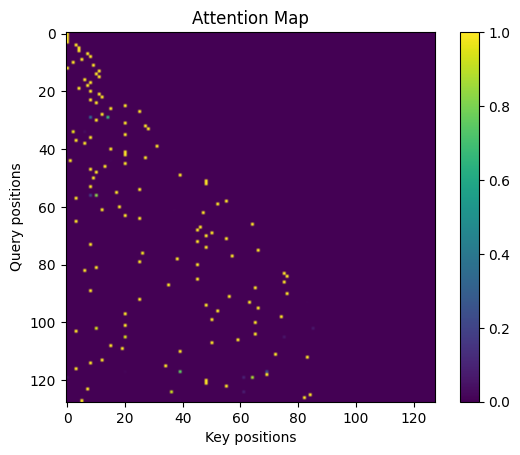

In [60]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [61]:
output = attention @ V
output.shape

torch.Size([4096, 128, 64])

In [62]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([4096, 128, 32]),
 tensor([[[-0.0897,  1.6308,  0.0922,  ..., -2.1423,  0.9986, -2.0971],
          [-0.0897,  1.6308,  0.0922,  ..., -2.1423,  0.9986, -2.0971],
          [-0.0897,  1.6308,  0.0922,  ..., -2.1423,  0.9986, -2.0971],
          ...,
          [ 1.7773,  2.3060,  0.5643,  ..., -1.3436, -2.4573, -0.6887],
          [-0.9745,  1.4660,  1.6428,  ..., -4.6745,  1.2911, -1.1973],
          [-0.6310,  3.7195, -0.0601,  ...,  0.5750,  2.8908, -0.1654]],
 
         [[-1.3166, -0.3036, -0.2224,  ..., -2.6039,  0.3076, -0.6619],
          [-1.3166, -0.3036, -0.2224,  ..., -2.6039,  0.3076, -0.6619],
          [ 2.3832,  1.1678, -1.0001,  ...,  0.0783, -0.2223,  1.4877],
          ...,
          [-1.0081,  0.4266, -0.9954,  ..., -1.5582,  1.2216,  1.1446],
          [ 0.4745,  1.9698, -0.2012,  ..., -2.1733,  0.9974, -3.2838],
          [ 2.4716,  1.8743, -1.1122,  ...,  1.2921,  1.2907, -2.2242]],
 
         [[-1.3166, -0.3036, -0.2224,  ..., -2.6039,  0.3076, -0.6619]

In [63]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        #self.W_q = nn.Linear(embed_size, head_size)
        #self.W_k = nn.Linear(embed_size, head_size)
        #self.W_v = nn.Linear(embed_size, head_size)

        self.W_qkv = nn.Linear(embed_size, head_size * 3)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        #Q = self.W_q(x)
        #K = self.W_k(x)
        #V = self.W_v(x)

        QKV = self.W_qkv(x)
        Q, K, V = torch.chunk(QKV, 3, dim=-1)
        
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[ 1.2570e+00,  1.6541e-01, -4.8568e-01],
          [ 3.6661e-01,  1.5060e-01,  1.1578e-01],
          [ 1.6819e-01,  2.6870e-02,  1.7812e-01],
          [-3.2948e-02,  8.9272e-02,  2.9347e-01],
          [ 2.4053e-02,  1.0140e-01,  2.5155e-01],
          [ 3.7239e-02,  2.1512e-02,  3.1094e-01],
          [ 4.8500e-02,  3.9900e-02,  3.6402e-01],
          [ 3.8182e-02,  1.1462e-01,  3.6363e-01],
          [-7.8506e-02,  6.3655e-02,  4.3404e-01],
          [-9.9505e-02,  3.4166e-02,  3.5749e-01],
          [-5.7823e-02, -9.8674e-04,  3.3862e-01],
          [-6.1365e-02,  5.0814e-04,  2.9103e-01],
          [-1.4040e-01,  7.7215e-02,  3.5518e-01],
          [-9.7267e-02,  3.5375e-02,  3.6140e-01],
          [-3.8401e-02, -2.3534e-02,  2.9324e-01],
          [ 4.1875e-03, -6.6366e-02,  2.6680e-01],
          [ 2.4781e-02, -8.1971e-02,  2.3925e-01],
          [-1.8143e-01,  2.6806e-02,  3.7506e-01],
          [-5.3279e-02, -6.9665e-02,  3.0349e-01],
     

In [64]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.0261,  0.4611,  0.3442,  ...,  0.5555, -0.2317,  0.1973],
          [ 0.2060,  0.3117,  0.1913,  ...,  0.3031, -0.2036,  0.3380],
          [-0.0751,  0.3655,  0.0839,  ...,  0.0051,  0.0599,  0.2242],
          ...,
          [ 0.2115,  0.2044,  0.0977,  ...,  0.2390, -0.1563,  0.1414],
          [ 0.2004,  0.2326,  0.1098,  ...,  0.2995, -0.1149,  0.0622],
          [ 0.2116,  0.2045,  0.0978,  ...,  0.2397, -0.1579,  0.1433]]],
        grad_fn=<ViewBackward0>))

In [65]:
a = torch.randn((3, 3))
a

tensor([[ 0.4345, -1.1426, -2.0027],
        [-0.2326,  0.4816,  0.2240],
        [-0.5395, -0.7686, -0.5910]])

In [66]:
tril = torch.tril(torch.ones(3, 3))
tril

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [67]:
mask = tril == 0
mask

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

In [68]:
a.masked_fill(mask, float("-inf"))

tensor([[ 0.4345,    -inf,    -inf],
        [-0.2326,  0.4816,    -inf],
        [-0.5395, -0.7686, -0.5910]])

In [69]:
class FastMultiHeadAttention(nn.Module):
    def __init__(self, n_heads):
        nn.Module.__init__(self)
        embed_size = CONFIG["embed_size"]
        block_size = CONFIG["seq_len"]
        head_size = embed_size // n_heads
        self.n_heads = n_heads
        self.head_size = head_size
        self.W_qkv = nn.Linear(embed_size, embed_size * 3)
        self.W_o = nn.Linear(embed_size, embed_size)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        QKV = self.W_qkv(x) # (B, T, 3 * embed_size)
        Q, K, V = torch.chunk(QKV, 3, dim=-1)
        Q = Q.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size)).to(x.device)
        mask = self.tril[:T, :T].bool().unsqueeze(0).unsqueeze(0)
        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1)
        V_scaled = attention @ V # (B, n_heads, T, head_size)
        V_scaled_t = V_scaled
        V_scaled_t_realigned = V_scaled_t.transpose(1, 2).contiguous().view(B, T, C)
        output = self.W_o(V_scaled_t_realigned) 
        return output

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = FastMultiHeadAttention(2)(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.2292,  0.1553,  0.0710,  ...,  0.1255, -0.1721, -0.2606],
          [-0.5403, -0.0295, -0.0983,  ...,  0.0571, -0.1793, -0.2129],
          [-0.4675,  0.0064, -0.1768,  ...,  0.1947, -0.2499, -0.1715],
          ...,
          [-0.1761, -0.1197,  0.0288,  ...,  0.1293, -0.1734, -0.0635],
          [-0.1483, -0.0796,  0.0292,  ...,  0.0396, -0.1392, -0.0306],
          [-0.1709, -0.0526, -0.0051,  ...,  0.0715, -0.1560, -0.0364]]],
        grad_fn=<ViewBackward0>))

In [70]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.0449,  0.0047, -0.1010,  ...,  0.1479, -0.0570, -0.0077],
          [-0.0796, -0.0168, -0.0569,  ...,  0.1250,  0.0283, -0.0401],
          [-0.0792,  0.0431, -0.0592,  ...,  0.1191,  0.0114,  0.0182],
          ...,
          [-0.0455,  0.0438, -0.0233,  ...,  0.0839, -0.0144, -0.0046],
          [-0.0485,  0.0411, -0.0226,  ...,  0.0727, -0.0213,  0.0082],
          [-0.0451,  0.0434, -0.0233,  ...,  0.0832, -0.0141, -0.0035]]],
        grad_fn=<ViewBackward0>))

In [71]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = FastMultiHeadAttention(CONFIG["num_heads"])
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        if CONFIG["layer_norm_enabled"]:
            x = x + self.head(self.ln1(x))  # Normalize input to attention
        else:
            x = x + self.head(x)
        
        if CONFIG["layer_norm_enabled"]:
            x = x + self.ffn(self.ln2(x))  # Normalize input to FFN
        else:
            x = x + self.ffn(x)
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.3429, -0.5731, -0.6983,  ..., -1.4301, -0.0319, -1.5153],
          [-0.4499, -0.4259, -0.0138,  ...,  0.4180, -0.9689, -0.3600],
          [ 0.3572,  0.7709, -2.1744,  ...,  1.3493,  0.0591,  1.8049],
          ...,
          [ 0.3397, -1.2835, -0.4638,  ..., -0.2187,  0.3972, -1.4396],
          [ 2.0090,  1.0812,  1.3844,  ...,  0.6218, -0.8239, -1.5988],
          [-0.2995, -0.4434, -1.0557,  ..., -1.2446,  0.5611, -0.9666]]],
        grad_fn=<AddBackward0>))

In [72]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 59, 56, 63,
         63, 66]])

In [73]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        if CONFIG["layer_norm_enabled"]: x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 81]),
 tensor([ 6.1668e-01,  5.4680e-01, -6.5140e-02,  3.3977e-01, -7.9634e-01,
          5.5218e-01,  5.0460e-01, -7.7517e-01, -5.9728e-01, -3.7437e-01,
         -3.3912e-01,  1.6285e-01,  1.5679e-01,  9.0950e-02, -3.6440e-01,
         -2.7577e-01, -5.0581e-01,  2.5587e-01,  3.2705e-01, -1.7626e+00,
          2.2496e-02, -5.8927e-01,  2.4866e-01,  3.0028e-01, -3.3675e-01,
          8.3860e-01, -1.1671e-01,  7.4697e-02,  1.2052e+00, -7.1892e-01,
         -2.5251e-01,  2.3797e-02,  6.4881e-01,  2.8418e-01, -3.4051e-01,
          3.0515e-01,  1.1203e-01,  3.8270e-01,  4.7139e-02,  2.5976e-01,
          2.1519e-01, -3.9972e-01, -2.8493e-01,  1.7661e-01, -2.8017e-01,
          4.0064e-01,  6.6143e-01,  5.2911e-01,  1.0765e+00, -4.5838e-03,
          1.2060e+00, -5.5032e-01,  3.0441e-01,  8.7963e-01, -4.9442e-01,
         -7.4885e-04,  6.5517e-01,  5.6917e-01,  5.8490e-01, -5.9824e-02,
         -1.3123e-01, -3.1271e-01, -1.3736e-01,  2.3668e-02, -7.2396e-01,
          2

In [74]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:Lord Of Th
y:ord Of The


In [75]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:at lost la
y:t lost lan
---
x:ir hearts:
y:r hearts: 
---
x:was passin
y:as passing
---
x: but you s
y:but you sh
---
x:em bore th
y:m bore the
---
x:errily in 
y:rrily in t
---
x:em. And th
y:m. And the
---
x: were beau
y:were beaut
---
x:Pippin sai
y:ippin said
---
x:ll eyed St
y:l eyed Str
---


In [76]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(81, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (head): FastMultiHeadAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=81, bias=True)
  (ln_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

In [77]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

In [78]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 100
losses = []
grad_norms = []

for epoch in range(num_epochs):
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x, y in batch_bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        grad_norm = get_grad_norm(model)
        grad_norms.append(grad_norm)
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{grad_norm:.4f}")

Epoch 30/100:  21%|██        | 50/243 [00:15<00:58,  3.29it/s, grad_norm=0.7881, loss=0.9845]


KeyboardInterrupt: 

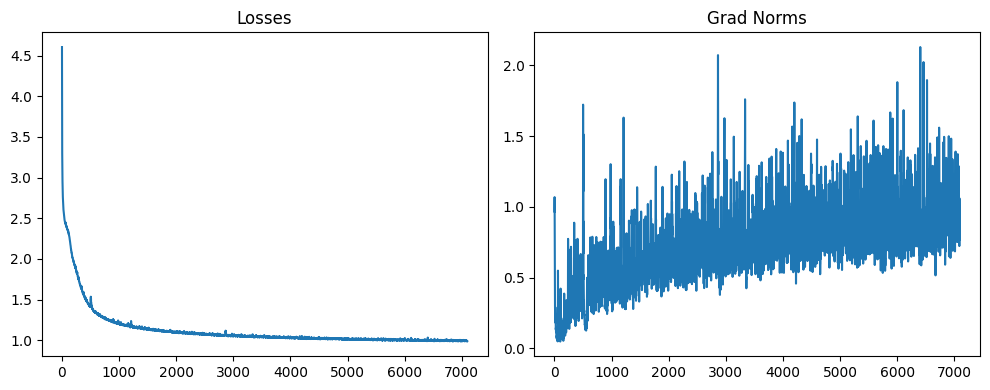

In [79]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left plot
axes[0].plot(losses)
axes[0].set_title("Losses")

# Right plot
axes[1].plot(grad_norms)   # replace with your second dataset
axes[1].set_title("Grad Norms")

plt.tight_layout()
plt.show()

In [80]:
model.eval()
print(model.generate("Frodo picked up the sword", max_len=1024))

 water that are wanting of yoaks began to tiring brighing for fawd. We related to the fire a great danger and swayfals went came to a cold blunted hours. Then there was a brave driving Towards the compose and out of the world into bed. Frodo! The table of Hobbits sat tried together weary path, I went ask you could not be housed in business and said indeed, or glittering and the other herses to one. I should say, so Bilbo messenging helm slopes and otherwise."
"I said nothing," said Gandalf, "you swimuled me by all the others. When many young old untoes only elanor, Lady shaped, thinking his close beside of their longer and keen.
"No!" said Bilbo. "And I have missed learned him. I say, but only a golden haze. I think now shivly away, there were many denses seemed to be talking-chiling, getting voices. Following the Hoaring hill.
The Bree-land again!"
He laughed. There they came no doubt-footstepsilves must has when he here, and I tried over him into the darkness.
The putting ran gold to

In [ ]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")